# Stress-Testing Helpers on a New Dataset

The helpers built throughout this course were developed and tested on HR analytics data.
This lesson runs the **exact same pipeline** on a different dataset: the **Telco Customer Churn** dataset.

The task is structurally similar — binary classification — but the data is different in ways that matter:

| | HR Analytics | Telco Churn |
|---|---|---|
| Rows | ~5,000 | ~7,000 |
| Positive class rate | ~8% | ~26% |
| Domain | Employee attrition | Customer churn |

The goal is not to build the best model. It is to observe: **do the helpers still behave sensibly on data they have never seen?**


## 1 — Setup

The completed notebook includes saved outputs so you can review the expected result without my local `.env` file. To rerun the Gemini cells, create your own `.env` file in the project root with `GEMINI_API_KEY=your-gemini-api-key-here`.


In [ ]:
%pip install -q google-genai pandas scikit-learn matplotlib python-dotenv


In [5]:
import os
import sys
import urllib.request
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from google import genai

# --- helper paths (same as 6.1) ---
sys.path.append(str(Path("../01-Exploratory-Data-Analysis-Helpers").resolve()))
sys.path.append(str(Path("../02-Preprocessing-Helpers").resolve()))
sys.path.append(str(Path("../03-Modeling-Helpers").resolve()))
sys.path.append(str(Path("../04-Evaluation-Helpers").resolve()))

from eda_summary_helper import eda_summary_helper
from eda_visual_helpers import eda_visual_helper
from preprocessing_pipeline import preprocessing_pipeline
from classification_helper import classification_helper
from classification_eval_helper import (
    compute_classification_metrics,
    flag_anomalies,
)

warnings.filterwarnings("ignore")
load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

RAW_PATH = "../../data/telco_churn.csv"
TARGET_COL = "Churn"
GEN_CONFIG = {"temperature": 0.0, "seed": 42}
pd.set_option("display.max_colwidth", None)


## 2 — EDA

### About the Dataset

**Telco Customer Churn** — originally published by IBM as a sample dataset, 
widely used as a benchmark for binary classification.

- **Source:** IBM Sample Datasets (via [treselle-systems/customer_churn_analysis](https://github.com/treselle-systems/customer_churn_analysis/blob/master/WA_Fn-UseC_-Telco-Customer-Churn.csv))
- **Rows:** 7,043 customers
- **Columns:** 21 features + 1 target (`Churn`: Yes / No)
- **Positive class rate:** ~26% churned

**What the data contains:**
- **Demographics** — gender, SeniorCitizen, Partner, Dependents
- **Account info** — tenure, Contract type, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
- **Services subscribed** — PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

**Known data quality issue:**  
`TotalCharges` is stored as a string in the raw file — 11 new customers with no charges have a space instead of `0`. 
This must be coerced to numeric before the preprocessing pipeline can run.


In [2]:
# Download the dataset if not already present
if not Path(RAW_PATH).exists():
    url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    Path(RAW_PATH).parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, RAW_PATH)
    print(f"Downloaded to {RAW_PATH}")
else:
    print(f"Found: {RAW_PATH}")


Found: ../../data/telco_churn.csv


In [3]:
# TotalCharges is stored as string in the raw file — coerce to numeric.
# Also drop customerID so the preprocessing pipeline doesn't carry an
# identifier column through to the model.
df_raw = pd.read_csv(RAW_PATH)
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
df_raw = df_raw.drop(columns=["customerID"], errors="ignore")
df_raw.to_csv(RAW_PATH, index=False)

print(f"Shape: {df_raw.shape}")
print(
    f"Churn rate: {df_raw[TARGET_COL].value_counts(normalize=True).round(3).to_dict()}"
)
df_raw.head(3)


Shape: (7043, 20)
Churn rate: {'No': 0.735, 'Yes': 0.265}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [6]:
eda_result = eda_summary_helper(
    question="Summarise this dataset for a classification task predicting Churn. Flag any data quality issues, class imbalance or columns that look problematic.",
    frame=df_raw,
)
print(eda_result)


              Column    Dtype  Non-Null Count  Missing Count  Missing %  \
0             gender      str            7043              0   0.000000   
1      SeniorCitizen    int64            7043              0   0.000000   
2            Partner      str            7043              0   0.000000   
3         Dependents      str            7043              0   0.000000   
4             tenure    int64            7043              0   0.000000   
5       PhoneService      str            7043              0   0.000000   
6      MultipleLines      str            7043              0   0.000000   
7    InternetService      str            7043              0   0.000000   
8     OnlineSecurity      str            7043              0   0.000000   
9       OnlineBackup      str            7043              0   0.000000   
10  DeviceProtection      str            7043              0   0.000000   
11       TechSupport      str            7043              0   0.000000   
12       StreamingTV     

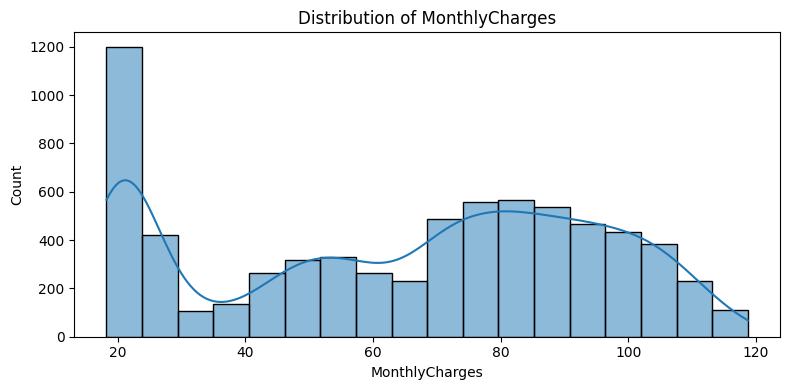

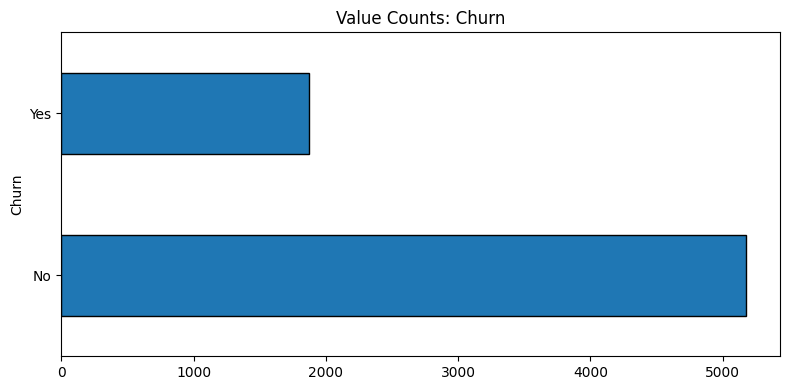

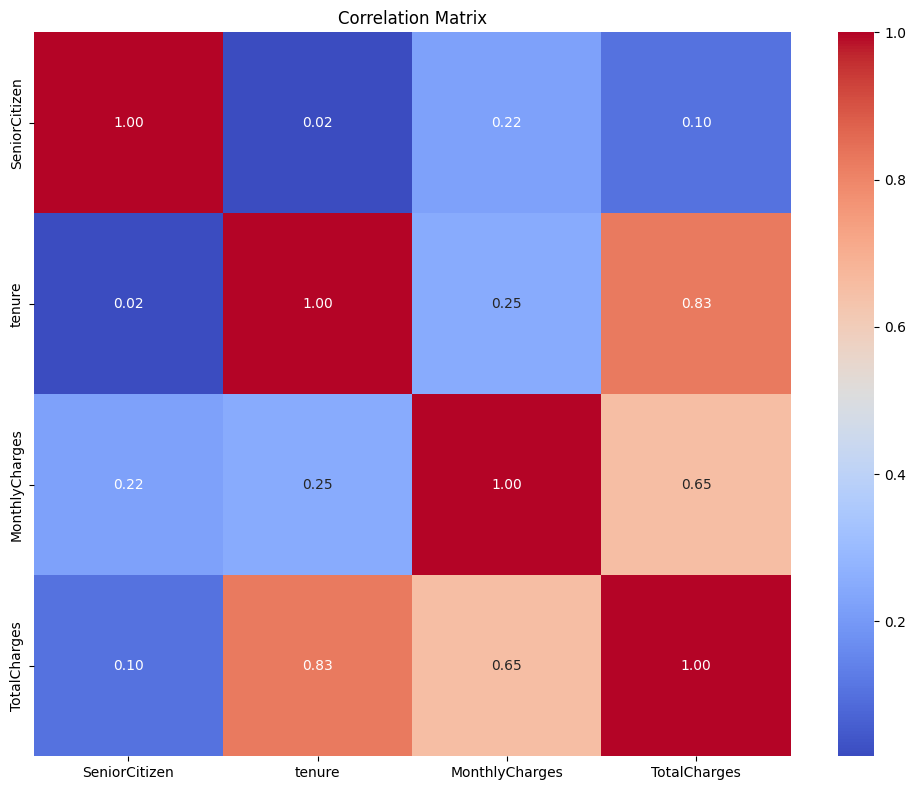

{'tool': 'plot_correlation', 'args': {}}

In [7]:
df_numeric = df_raw.select_dtypes(include="number").assign(Churn=df_raw[TARGET_COL])

eda_visual_helper(
    question="Show the distribution of MonthlyCharges.",
    frame=df_numeric,
)

eda_visual_helper(
    question="Show churn counts.",
    frame=df_numeric,
)

eda_visual_helper(
    question="Show the correlation matrix.",
    frame=df_numeric,
)


## 3 — Preprocessing

In [10]:
result = preprocessing_pipeline(
    raw_path=RAW_PATH,
    target_col=TARGET_COL,
    task="classification",
)
X_train, X_test = result.X_train_enc, result.X_test_enc
y_train, y_test = result.y_train, result.y_test

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(
    f"Class balance (train): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}"
)


Loaded: (7043, 20)
Split raw: train=(5634, 20) test=(1409, 20)
Cleaned: train=(5634, 20) missing=0 | test=(1409, 20) missing=0
Encoded: train=(5634, 24) test=(1409, 24)
Train: (5634, 24)  |  Test: (1409, 24)
Class balance (train): {0: 0.735, 1: 0.265}


## 4 — Modeling

The classification helper selects a model, tunes hyperparameters, and returns predictions.
It explains which model it chose and why it rejected the alternatives.


In [11]:
results = classification_helper(X_train, X_test, y_train, y_test)

print(f"Model selected : {results['model_name']}")
print(f"Init kwargs    : {results['init_kwargs']}")


Model selected : sklearn.linear_model.LogisticRegression
Init kwargs    : {'random_state': 42, 'class_weight': 'balanced'}


## 5 — Evaluation

Metrics are computed from predictions — not generated by the LLM. The LLM then flags anomalies on the metrics dict.


In [12]:
metrics = compute_classification_metrics(
    y_test,
    results["y_pred"],
    results["y_proba"],
)
pd.DataFrame([metrics])


,threshold,accuracy,precision,recall,f1,class_ratio,predicted_positive_rate,confusion_matrix,roc_auc
0,0.5,0.738112,0.504274,0.78877,0.615224,0.265436,0.415188,"[[745, 290], [79, 295]]",0.841871


In [13]:
# Baseline check — does the model beat always predicting the majority class?
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

pd.DataFrame(
    {
        "metric": ["accuracy", "f1 (weighted)"],
        "dummy": [
            round(dummy.score(X_test, y_test), 3),
            round(f1_score(y_test, dummy.predict(X_test), average="weighted"), 3),
        ],
        "our_model": [
            round(metrics["accuracy"], 3),
            round(f1_score(y_test, results["y_pred"], average="weighted"), 3),
        ],
    }
)


,metric,dummy,our_model
0,accuracy,0.735,0.738
1,f1 (weighted),0.622,0.752


In [14]:
flags = flag_anomalies(metrics)
pd.DataFrame(flags)


,flag,severity,explanation
0,Imbalanced Dataset,medium,"The positive class constitutes only 26.5% of the dataset (`class_ratio`), indicating a moderately imbalanced dataset. This makes overall accuracy a potentially misleading metric, and emphasizes the importance of precision, recall, and F1-score for evaluating performance on the minority class."
1,Significant Precision-Recall Imbalance,medium,"The model exhibits high recall (0.789) but relatively low precision (0.504) at the chosen threshold. This means that while it correctly identifies a large proportion of actual positive cases (few false negatives), nearly half of its positive predictions are incorrect (many false positives). This behavior might be acceptable or even desired depending on the specific business problem (e.g., prioritizing recall in medical screening), but it highlights a strong bias towards minimizing false negatives at the expense of increasing false positives."
2,Accuracy only marginally better than majority class baseline,medium,"The overall accuracy (0.738) is only slightly higher than simply predicting the majority (negative) class for all instances, which would yield an accuracy of approximately 0.735 (1 - `class_ratio`). While the model does perform better, this small margin, coupled with the precision-recall imbalance, suggests that the model's overall performance at this threshold is not significantly superior to a trivial baseline, especially concerning its ability to correctly identify both classes proportionally."
